# Imports

In [1]:
import os
import warnings
from rich import print

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import palantir
import scvi
import torch

In [2]:
plt.rcParams['savefig.dpi'] = 300
%matplotlib inline

# Functions

In [3]:
def log_transform(ad, ps=0.1):
    """
    Applies a pseudo-count log2 transformation to the data in an AnnData object.

    The transformation is defined as log2(x + ps) - log2(ps), where x is the original data
    and ps is the pseudo-count. The purpose of the pseudo-count is to avoid taking the log of zero.

    Parameters
    ----------
    ad: AnnData
        The AnnData object containing the data to be transformed.

    ps: float, optional
        The pseudo-count to be added to the data before taking the logarithm.
        The default value is 0.1.

    Returns
    -------
    None
        The function modifies the AnnData object in-place.
    """

    # Check if the data in the Anndata object is a numpy array
    if not isinstance(ad.X.data, np.ndarray):
        raise TypeError("The data in the AnnData object should be a numpy array.")

    # Check if the pseudo-count is a positive number
    if ps <= 0:
        raise ValueError("The pseudo-count should be a positive number.")

    # Apply the log2 transformation
    ad.X.data = np.log2(ad.X.data + ps) - np.log2(ps)

# Male - Run 60

### Duodenum

In [4]:
input_dir = 'datasets/May-Zhang et al/Run0060_Male/'

In [5]:
zhang_ad_duo_male = sc.read_mtx(input_dir + 'GSM4635445_10x-Run0060_Male-Doudenum-Neurons-Fixed_matrix.mtx.gz')
zhang_ad_duo_male

AnnData object with n_obs × n_vars = 30211 × 6794880

In [6]:
barcodes = pd.read_csv(input_dir + 'GSM4635445_10x-Run0060_Male-Doudenum-Neurons_Fixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [7]:
genes = pd.read_csv(input_dir + 'GSM4635445_10x-Run0060_Male-Doudenum-Neurons-Fixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [8]:
zhang_ad_duo_male = zhang_ad_duo_male.T 
zhang_ad_duo_male.obs = barcodes
zhang_ad_duo_male.var = genes
zhang_ad_duo_male.var_names_make_unique()
zhang_ad_duo_male

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [9]:
zhang_ad_duo_male.var_names = zhang_ad_duo_male.var['gene_name']
zhang_ad_duo_male.obs_names = zhang_ad_duo_male.obs['barcode']
zhang_ad_duo_male.layers['raw_counts'] = zhang_ad_duo_male.X.copy()

In [10]:
zhang_ad_duo_male.var["mt"] = zhang_ad_duo_male.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_duo_male,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [11]:
zhang_ad_duo_male.var_names_make_unique()

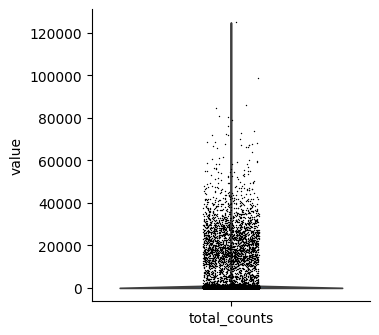

In [12]:
sc.pl.violin(zhang_ad_duo_male, 'total_counts')

In [13]:
use_cells = zhang_ad_duo_male.obs_names[
    (zhang_ad_duo_male.obs["total_counts"] > 10000)
    & (zhang_ad_duo_male.obs["total_counts"] < 40000)
]
zhang_ad_duo_male = zhang_ad_duo_male[use_cells, :]

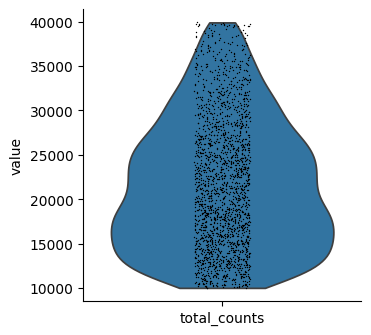

In [14]:
sc.pl.violin(zhang_ad_duo_male, 'total_counts')

In [15]:
sc.pp.filter_cells(zhang_ad_duo_male, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


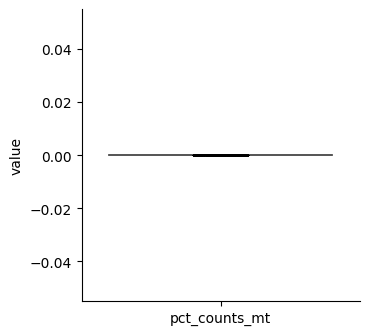

In [16]:
sc.pl.violin(zhang_ad_duo_male, 'pct_counts_mt')

In [17]:
sc.pp.filter_genes(zhang_ad_duo_male, min_cells=50)

In [18]:
sc.pp.normalize_total(zhang_ad_duo_male, target_sum=1e4)
zhang_ad_duo_male.layers["normalized_counts"] = zhang_ad_duo_male.X.copy()

log_transform(zhang_ad_duo_male)
zhang_ad_duo_male.layers["logcounts"] = zhang_ad_duo_male.X.copy()

In [19]:
sc.pp.highly_variable_genes(zhang_ad_duo_male, flavor="cell_ranger", n_top_genes=2000)

In [20]:
sc.tl.pca(zhang_ad_duo_male, mask_var="highly_variable")

In [21]:
sc.pp.neighbors(zhang_ad_duo_male, use_rep="X_pca")
sc.tl.umap(zhang_ad_duo_male)

/loc/scratch/41954361/ipykernel_14900/3573314125.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(zhang_ad_duo_male, resolution=0.5, key_added="leiden_0.5")


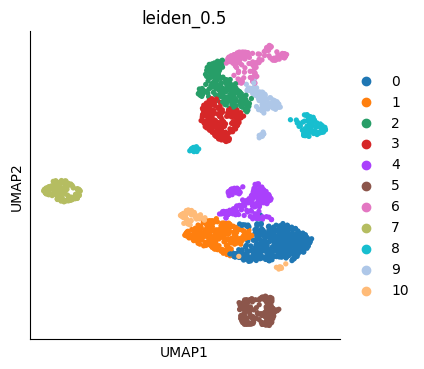

In [22]:
sc.tl.leiden(zhang_ad_duo_male, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_duo_male, color="leiden_0.5")

In [23]:
sc.pp.scrublet(zhang_ad_duo_male)

In [24]:
zhang_ad_duo_male.obs["log_n_counts"] = np.log10(zhang_ad_duo_male.obs["total_counts"])

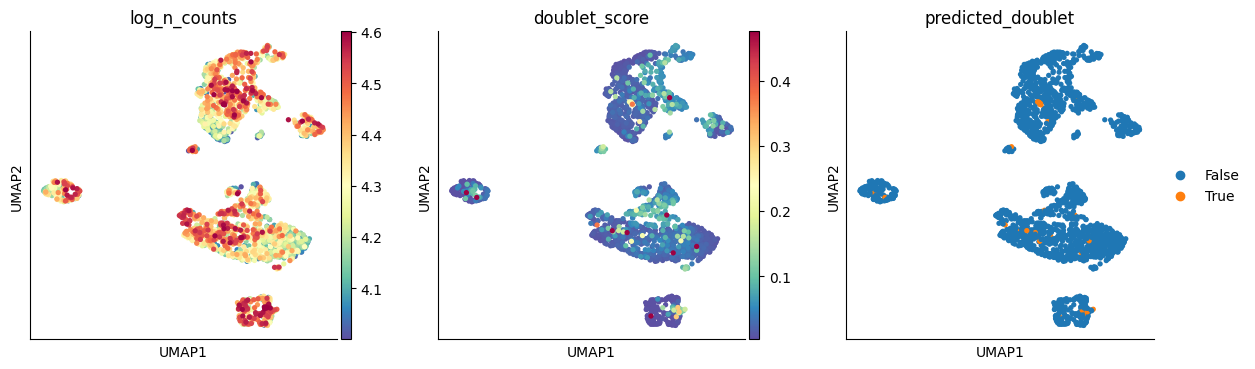

In [25]:
sc.pl.umap(zhang_ad_duo_male, color=["log_n_counts", "doublet_score", "predicted_doublet"])

In [26]:
zhang_ad_duo_male.shape

(2074, 13999)

In [27]:
zhang_ad_duo_male = zhang_ad_duo_male[zhang_ad_duo_male.obs['predicted_doublet'] == False].copy()
zhang_ad_duo_male.shape

(2044, 13999)

In [28]:
sc.pp.highly_variable_genes(zhang_ad_duo_male, flavor="cell_ranger", n_top_genes=2000)

In [29]:
sc.tl.pca(zhang_ad_duo_male, mask_var="highly_variable")

In [30]:
sc.pp.neighbors(zhang_ad_duo_male, use_rep="X_pca")
sc.tl.umap(zhang_ad_duo_male)

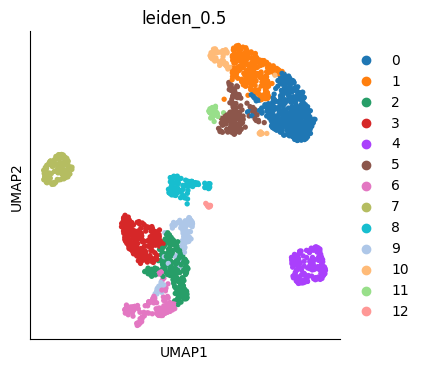

In [31]:
sc.tl.leiden(zhang_ad_duo_male, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_duo_male, color="leiden_0.5")

In [32]:
zhang_ad_duo_male.obs['run'] = 'Run0060 Male Fixed Duodenum' 

In [36]:
zhang_ad_duo_male.var = zhang_ad_duo_male.var.drop(columns={'gene_name'})

In [37]:
zhang_ad_duo_male.write_h5ad('may_zhang_male_60_duodenum_preprocessed.h5ad')

### Ileum

In [33]:
zhang_ad_ile_male = sc.read_mtx(input_dir + 'GSM4635441_10x-Run0060_Male-Ileum-Neurons-Fixed_matrix.mtx.gz')
zhang_ad_ile_male

AnnData object with n_obs × n_vars = 30211 × 6794880

In [38]:
barcodes = pd.read_csv(input_dir + 'GSM4635441_10x-Run0060_Male-Ileum-Neurons-Fixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [39]:
genes = pd.read_csv(input_dir + 'GSM4635441_10x-Run0060_Male-Ileum-Neurons-Fixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [40]:
zhang_ad_ile_male = zhang_ad_ile_male.T 
zhang_ad_ile_male.obs = barcodes
zhang_ad_ile_male.var = genes
zhang_ad_ile_male.var_names_make_unique()
zhang_ad_ile_male

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [41]:
zhang_ad_ile_male.var_names = zhang_ad_ile_male.var['gene_name']
zhang_ad_ile_male.obs_names = zhang_ad_ile_male.obs['barcode']
zhang_ad_ile_male.layers['raw_counts'] = zhang_ad_ile_male.X.copy()

In [42]:
zhang_ad_ile_male.var["mt"] = zhang_ad_ile_male.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_ile_male,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [43]:
zhang_ad_ile_male.var_names_make_unique()

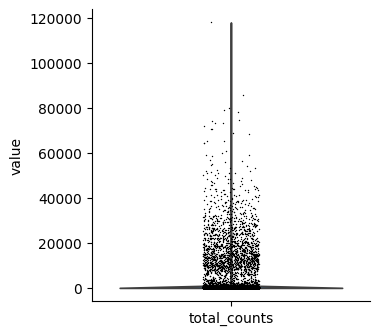

In [44]:
sc.pl.violin(zhang_ad_ile_male, 'total_counts')

In [45]:
use_cells = zhang_ad_ile_male.obs_names[
    (zhang_ad_ile_male.obs["total_counts"] > 10000)
    & (zhang_ad_ile_male.obs["total_counts"] < 40000)
]
zhang_ad_ile_male = zhang_ad_ile_male[use_cells, :]

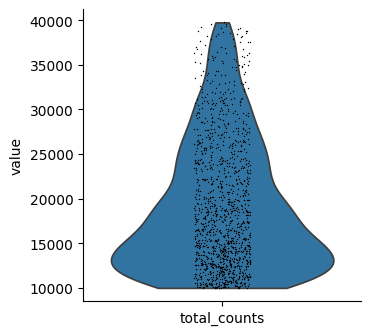

In [46]:
sc.pl.violin(zhang_ad_ile_male, 'total_counts')

In [47]:
sc.pp.filter_cells(zhang_ad_ile_male, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [48]:
sc.pp.filter_genes(zhang_ad_ile_male, min_cells=50)

In [49]:
sc.pp.normalize_total(zhang_ad_ile_male, target_sum=1e4)
zhang_ad_ile_male.layers["normalized_counts"] = zhang_ad_ile_male.X.copy()

log_transform(zhang_ad_ile_male)
zhang_ad_ile_male.layers["logcounts"] = zhang_ad_ile_male.X.copy()

In [50]:
sc.pp.highly_variable_genes(zhang_ad_ile_male, flavor="cell_ranger", n_top_genes=2000)

In [51]:
sc.tl.pca(zhang_ad_ile_male, mask_var="highly_variable")

In [52]:
sc.pp.neighbors(zhang_ad_ile_male, use_rep="X_pca")
sc.tl.umap(zhang_ad_ile_male)

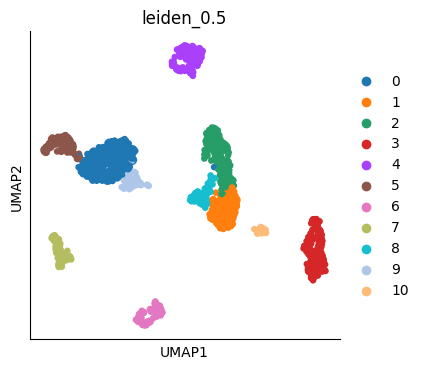

In [53]:
sc.tl.leiden(zhang_ad_ile_male, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_ile_male, color="leiden_0.5")

In [54]:
sc.pp.scrublet(zhang_ad_ile_male)

In [55]:
zhang_ad_ile_male.obs["log_n_counts"] = np.log10(zhang_ad_ile_male.obs["total_counts"])

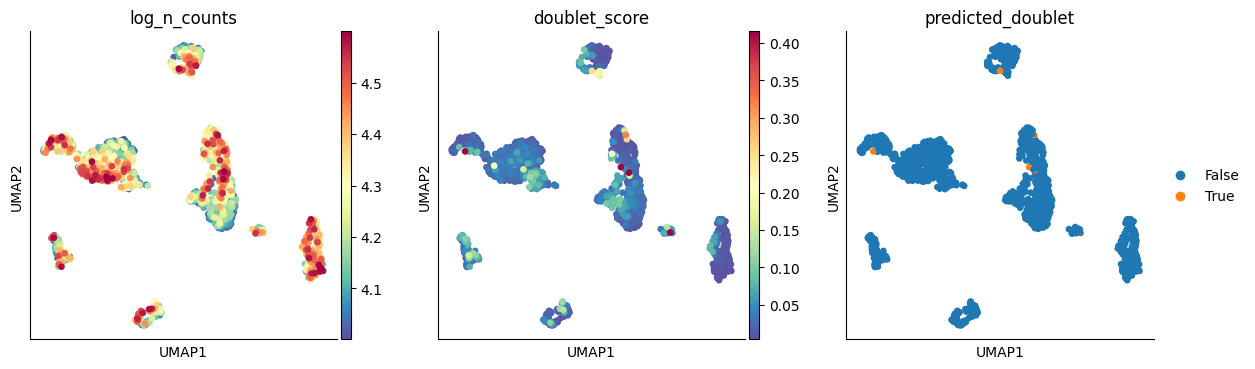

In [56]:
sc.pl.umap(zhang_ad_ile_male, color=["log_n_counts", "doublet_score", "predicted_doublet"])

In [57]:
zhang_ad_ile_male.shape

(1313, 13444)

In [58]:
zhang_ad_ile_male = zhang_ad_ile_male[zhang_ad_ile_male.obs['predicted_doublet'] == False].copy()
zhang_ad_ile_male.shape

(1306, 13444)

In [59]:
sc.pp.highly_variable_genes(zhang_ad_ile_male, flavor="cell_ranger", n_top_genes=2000)

In [60]:
sc.tl.pca(zhang_ad_ile_male, mask_var="highly_variable")

In [61]:
sc.pp.neighbors(zhang_ad_ile_male, use_rep="X_pca")
sc.tl.umap(zhang_ad_ile_male)

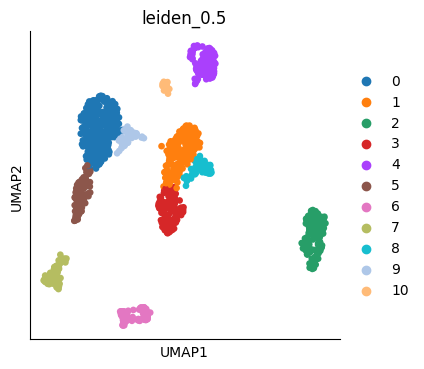

In [62]:
sc.tl.leiden(zhang_ad_ile_male, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_ile_male, color="leiden_0.5")

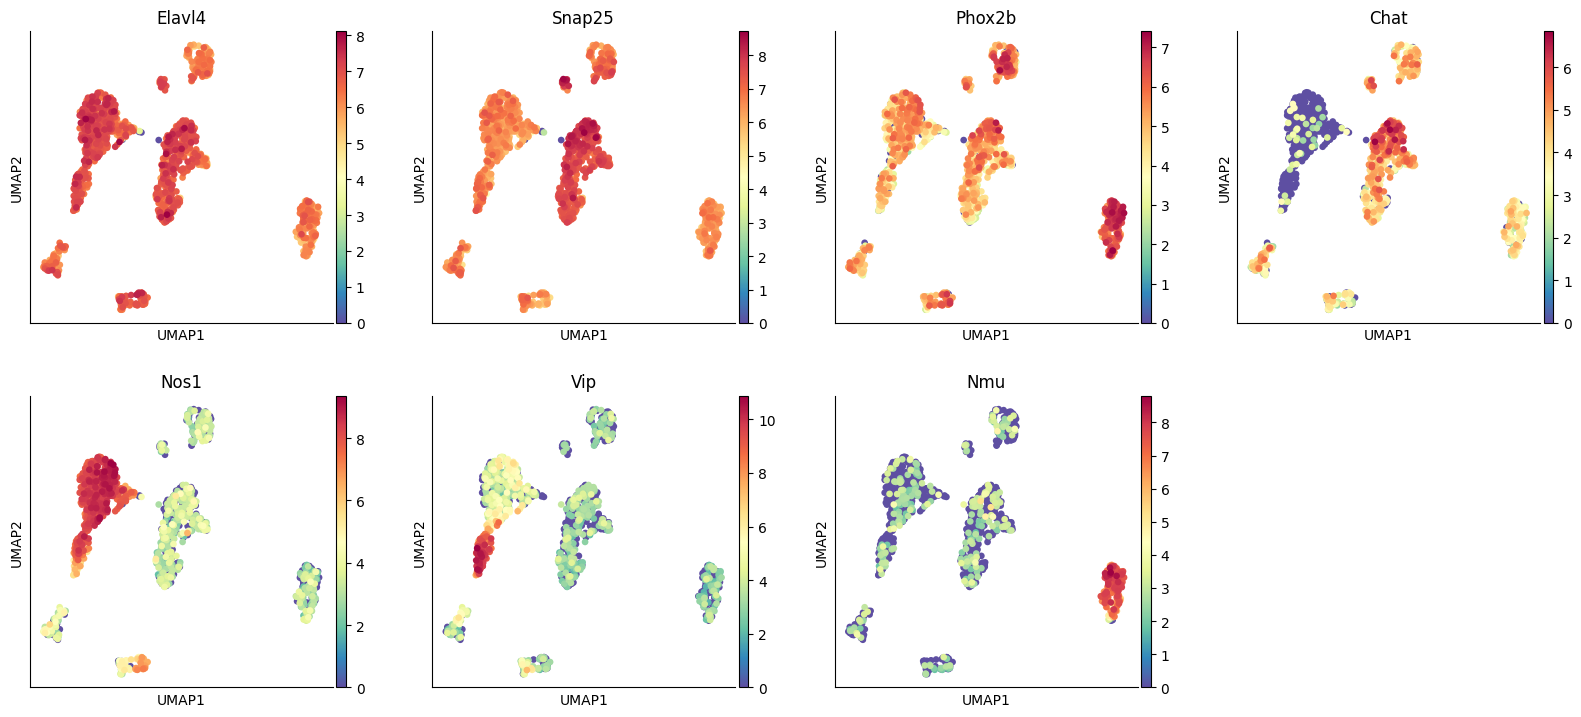

In [63]:
sc.pl.umap(zhang_ad_ile_male, color=['Elavl4', 'Snap25', 'Phox2b', 'Chat', 'Nos1', 'Vip', 'Nmu'])

In [64]:
zhang_ad_ile_male.obs['run'] = 'Run0060 Male Fixed Ileum' 

In [65]:
zhang_ad_ile_male.var = zhang_ad_ile_male.var.drop(columns={'gene_name'})

In [66]:
zhang_ad_ile_male.write_h5ad('may_zhang_male_60_ileum_preprocessed.h5ad')

### Colon

In [68]:
zhang_ad_col_male = sc.read_mtx(input_dir + 'GSM4635435_10x-Run0060-Male-Colon-Neurons-Fixed_matrix.mtx.gz')
zhang_ad_col_male

AnnData object with n_obs × n_vars = 30211 × 6794880

In [69]:
barcodes = pd.read_csv(input_dir + 'GSM4635435_10x-Run0060_Male-Colon-Neurons-Fixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [70]:
genes = pd.read_csv(input_dir + 'GSM4635435_10x-Run0060_Male-Colon-Neurons-Fixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [71]:
zhang_ad_col_male = zhang_ad_col_male.T 
zhang_ad_col_male.obs = barcodes
zhang_ad_col_male.var = genes
zhang_ad_col_male.var_names_make_unique()
zhang_ad_col_male

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [72]:
zhang_ad_col_male.var_names = zhang_ad_col_male.var['gene_name']
zhang_ad_col_male.obs_names = zhang_ad_col_male.obs['barcode']
zhang_ad_col_male.layers['raw_counts'] = zhang_ad_col_male.X.copy()

In [73]:
zhang_ad_col_male.var["mt"] = zhang_ad_col_male.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_col_male,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [74]:
zhang_ad_col_male.var_names_make_unique()

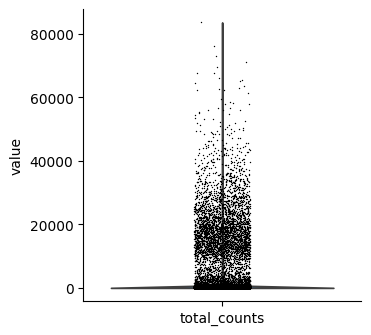

In [75]:
sc.pl.violin(zhang_ad_col_male, 'total_counts')

In [76]:
use_cells = zhang_ad_col_male.obs_names[
    (zhang_ad_col_male.obs["total_counts"] > 10000)
    & (zhang_ad_col_male.obs["total_counts"] < 40000)
]
zhang_ad_col_male = zhang_ad_col_male[use_cells, :]

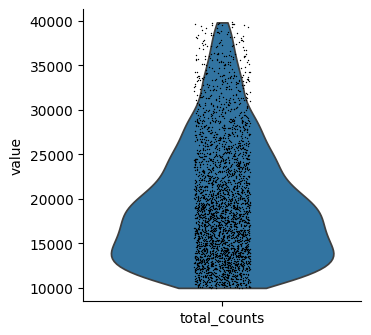

In [77]:
sc.pl.violin(zhang_ad_col_male, 'total_counts')

In [78]:
sc.pp.filter_cells(zhang_ad_col_male, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [79]:
sc.pp.filter_genes(zhang_ad_col_male, min_cells=50)

In [80]:
sc.pp.normalize_total(zhang_ad_col_male, target_sum=1e4)
zhang_ad_col_male.layers["normalized_counts"] = zhang_ad_col_male.X.copy()

log_transform(zhang_ad_col_male)
zhang_ad_col_male.layers["logcounts"] = zhang_ad_col_male.X.copy()

In [81]:
sc.pp.highly_variable_genes(zhang_ad_col_male, flavor="cell_ranger", n_top_genes=2000)

In [82]:
sc.tl.pca(zhang_ad_col_male, mask_var="highly_variable")

In [83]:
sc.pp.neighbors(zhang_ad_col_male, use_rep="X_pca")
sc.tl.umap(zhang_ad_col_male)

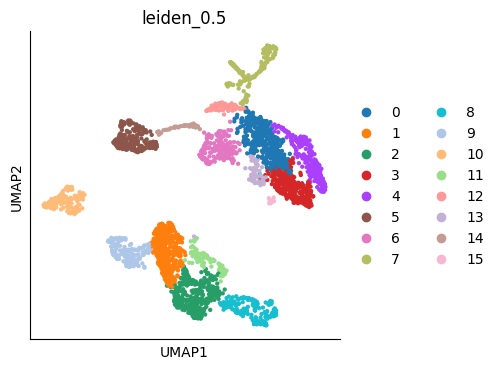

In [84]:
sc.tl.leiden(zhang_ad_col_male, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_col_male, color="leiden_0.5")

In [85]:
sc.pp.scrublet(zhang_ad_col_male)

In [86]:
zhang_ad_col_male.obs["log_n_counts"] = np.log10(zhang_ad_col_male.obs["total_counts"])

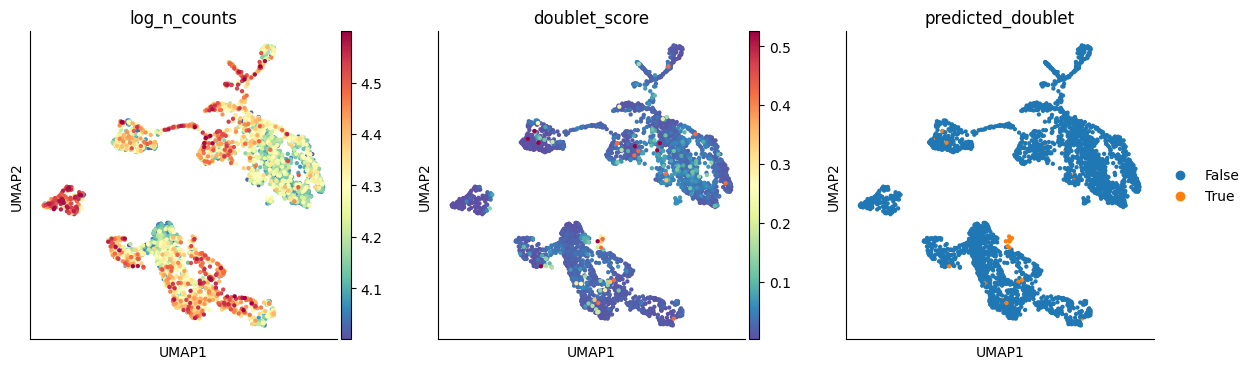

In [87]:
sc.pl.umap(zhang_ad_col_male, color=["log_n_counts", "doublet_score", "predicted_doublet"])

In [88]:
zhang_ad_col_male.shape

(3109, 14052)

In [89]:
zhang_ad_col_male = zhang_ad_col_male[zhang_ad_col_male.obs['predicted_doublet'] == False].copy()
zhang_ad_col_male.shape

(3077, 14052)

In [90]:
sc.pp.highly_variable_genes(zhang_ad_col_male, flavor="cell_ranger", n_top_genes=2000)

In [91]:
sc.tl.pca(zhang_ad_col_male, mask_var="highly_variable")

In [92]:
sc.pp.neighbors(zhang_ad_col_male, use_rep="X_pca")
sc.tl.umap(zhang_ad_col_male)

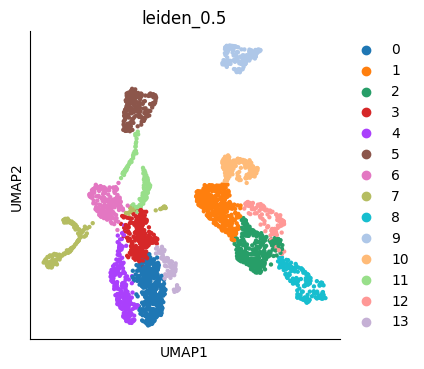

In [93]:
sc.tl.leiden(zhang_ad_col_male, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_col_male, color="leiden_0.5")

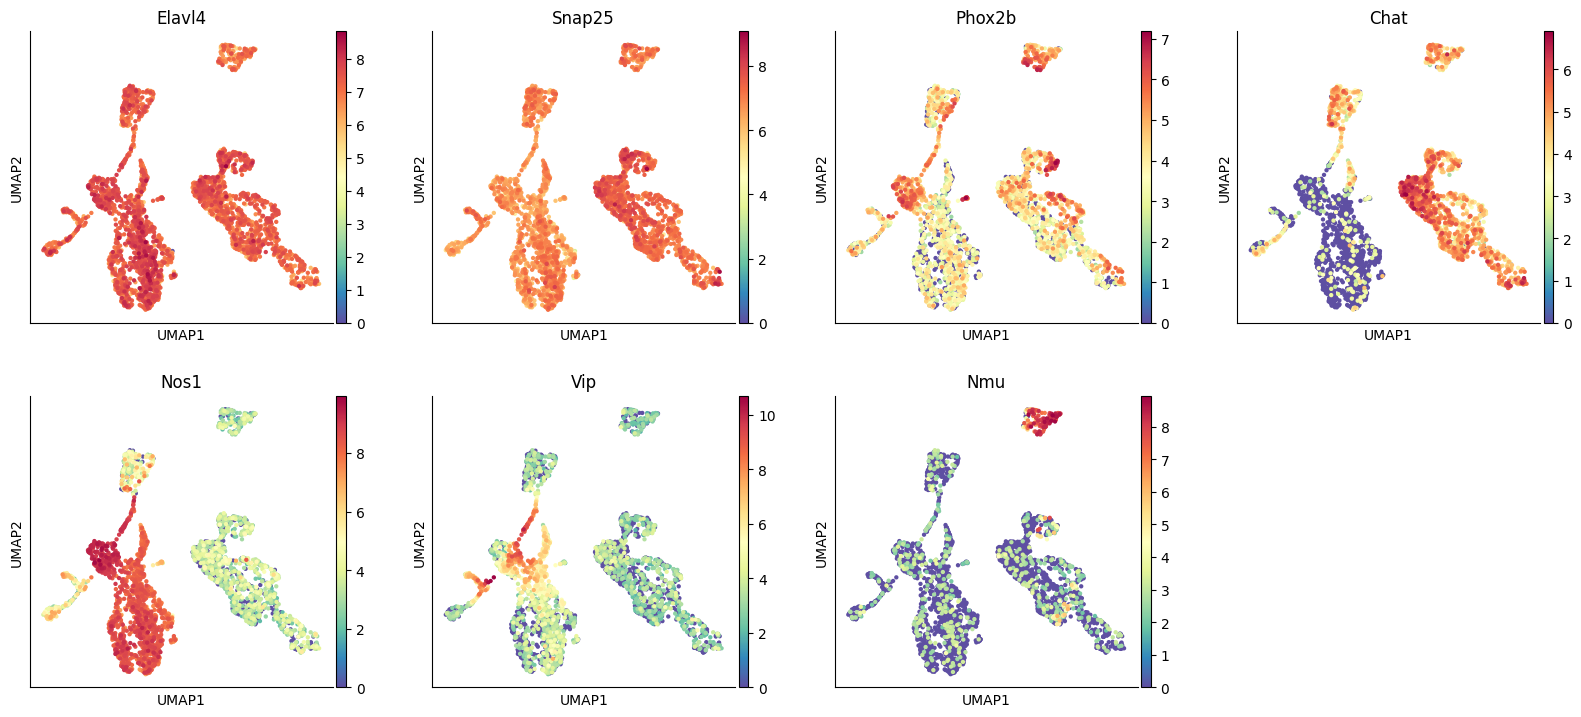

In [94]:
sc.pl.umap(zhang_ad_col_male, color=['Elavl4', 'Snap25', 'Phox2b', 'Chat', 'Nos1', 'Vip', 'Nmu'])

In [95]:
zhang_ad_col_male.obs['run'] = 'Run0060 Male Fixed Colon' 

In [96]:
zhang_ad_col_male.var = zhang_ad_col_male.var.drop(columns={'gene_name'})

In [97]:
zhang_ad_col_male.write_h5ad('may_zhang_male_60_colon_preprocessed.h5ad')

# Female - Run 52

### Ileum (unfixed)

In [98]:
input_dir = 'datasets/May-Zhang et al/Run0052_Female/'

In [99]:
zhang_ad_ile_unfixed_female = sc.read_mtx(input_dir + 'GSM4635440_10x-Run0052_Female-Ileum-Unfixed_matrix.mtx.gz')
zhang_ad_ile_unfixed_female

AnnData object with n_obs × n_vars = 30211 × 6794880

In [100]:
barcodes = pd.read_csv(input_dir + 'GSM4635440_10x-Run0052_Female-Ileum-Unfixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [101]:
genes = pd.read_csv(input_dir + 'GSM4635440_10x-Run0052_Female-Ileum-Unfixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [102]:
zhang_ad_ile_unfixed_female = zhang_ad_ile_unfixed_female.T 
zhang_ad_ile_unfixed_female.obs = barcodes
zhang_ad_ile_unfixed_female.var = genes
zhang_ad_ile_unfixed_female.var_names_make_unique()
zhang_ad_ile_unfixed_female

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [103]:
zhang_ad_ile_unfixed_female.var_names = zhang_ad_ile_unfixed_female.var['gene_name']
zhang_ad_ile_unfixed_female.obs_names = zhang_ad_ile_unfixed_female.obs['barcode']
zhang_ad_ile_unfixed_female.layers['raw_counts'] = zhang_ad_ile_unfixed_female.X.copy()

In [104]:
zhang_ad_ile_unfixed_female.var["mt"] = zhang_ad_ile_unfixed_female.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_ile_unfixed_female,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [105]:
zhang_ad_ile_unfixed_female.var_names_make_unique()

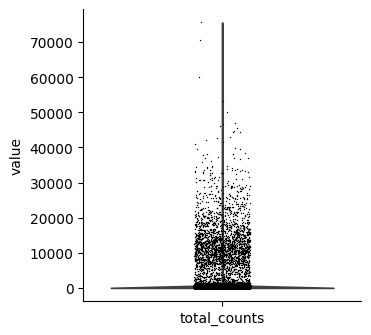

In [106]:
sc.pl.violin(zhang_ad_ile_unfixed_female, 'total_counts')

In [107]:
use_cells = zhang_ad_ile_unfixed_female.obs_names[
    (zhang_ad_ile_unfixed_female.obs["total_counts"] > 5000)
    & (zhang_ad_ile_unfixed_female.obs["total_counts"] < 25000)
]
zhang_ad_ile_unfixed_female = zhang_ad_ile_unfixed_female[use_cells, :]

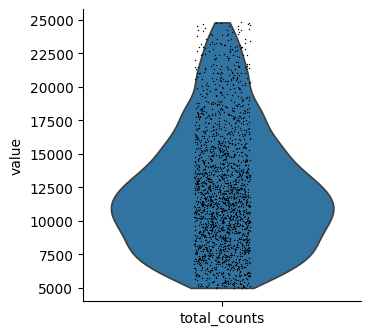

In [108]:
sc.pl.violin(zhang_ad_ile_unfixed_female, 'total_counts')

In [109]:
sc.pp.filter_cells(zhang_ad_ile_unfixed_female, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [110]:
sc.pp.filter_genes(zhang_ad_ile_unfixed_female, min_cells=50)

In [111]:
sc.pp.normalize_total(zhang_ad_ile_unfixed_female, target_sum=1e4)
zhang_ad_ile_unfixed_female.layers["normalized_counts"] = zhang_ad_ile_unfixed_female.X.copy()

log_transform(zhang_ad_ile_unfixed_female)
zhang_ad_ile_unfixed_female.layers["logcounts"] = zhang_ad_ile_unfixed_female.X.copy()

In [112]:
sc.pp.highly_variable_genes(zhang_ad_ile_unfixed_female, flavor="cell_ranger", n_top_genes=2000)

In [113]:
sc.tl.pca(zhang_ad_ile_unfixed_female, mask_var="highly_variable")

In [114]:
sc.pp.neighbors(zhang_ad_ile_unfixed_female, use_rep="X_pca")
sc.tl.umap(zhang_ad_ile_unfixed_female)

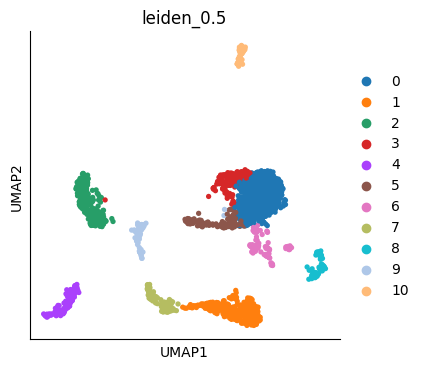

In [115]:
sc.tl.leiden(zhang_ad_ile_unfixed_female, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_ile_unfixed_female, color="leiden_0.5")

In [116]:
sc.pp.scrublet(zhang_ad_ile_unfixed_female)

In [117]:
zhang_ad_ile_unfixed_female.obs["log_n_counts"] = np.log10(zhang_ad_ile_unfixed_female.obs["total_counts"])

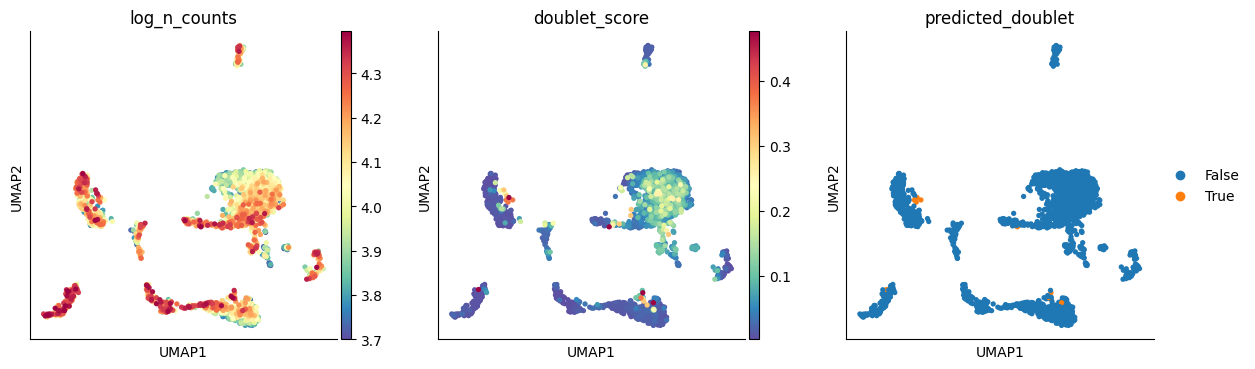

In [118]:
sc.pl.umap(zhang_ad_ile_unfixed_female, color=["log_n_counts", "doublet_score", "predicted_doublet"])

In [119]:
zhang_ad_ile_unfixed_female.shape

(2072, 13774)

In [120]:
zhang_ad_ile_unfixed_female = zhang_ad_ile_unfixed_female[zhang_ad_ile_unfixed_female.obs['predicted_doublet'] == False].copy()
zhang_ad_ile_unfixed_female.shape

(2063, 13774)

In [121]:
sc.pp.highly_variable_genes(zhang_ad_ile_unfixed_female, flavor="cell_ranger", n_top_genes=2000)

In [122]:
sc.tl.pca(zhang_ad_ile_unfixed_female, mask_var="highly_variable")

In [123]:
sc.pp.neighbors(zhang_ad_ile_unfixed_female, use_rep="X_pca")
sc.tl.umap(zhang_ad_ile_unfixed_female)

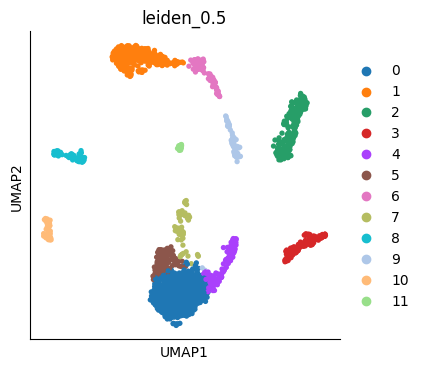

In [124]:
sc.tl.leiden(zhang_ad_ile_unfixed_female, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_ile_unfixed_female, color="leiden_0.5")

In [125]:
zhang_ad_ile_unfixed_female.obs['run'] = 'Run0052 Female Unfixed Ileum' 

In [126]:
zhang_ad_ile_unfixed_female.var = zhang_ad_ile_unfixed_female.var.drop(columns={'gene_name'})

In [127]:
zhang_ad_ile_unfixed_female.write_h5ad('may_zhang_female_52_ileum_preprocessed.h5ad')

### Ileum (fixed)

In [128]:
zhang_ad_ile_fixed_female = sc.read_mtx(input_dir + 'GSM4635439_10x-Run0052_Female-Ileum-Fixed_matrix.mtx.gz')
zhang_ad_ile_fixed_female

AnnData object with n_obs × n_vars = 30211 × 6794880

In [129]:
barcodes = pd.read_csv(input_dir + 'GSM4635439_10x-Run0052_Female-Ileum-Fixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [130]:
genes = pd.read_csv(input_dir + 'GSM4635439_10x-Run0052_Female-Ileum-Fixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [131]:
zhang_ad_ile_fixed_female = zhang_ad_ile_fixed_female.T 
zhang_ad_ile_fixed_female.obs = barcodes
zhang_ad_ile_fixed_female.var = genes
zhang_ad_ile_fixed_female.var_names_make_unique()
zhang_ad_ile_fixed_female

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [132]:
zhang_ad_ile_fixed_female.var_names = zhang_ad_ile_fixed_female.var['gene_name']
zhang_ad_ile_fixed_female.obs_names = zhang_ad_ile_fixed_female.obs['barcode']
zhang_ad_ile_fixed_female.layers['raw_counts'] = zhang_ad_ile_fixed_female.X.copy()

In [133]:
zhang_ad_ile_fixed_female.var["mt"] = zhang_ad_ile_fixed_female.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_ile_fixed_female,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [134]:
zhang_ad_ile_fixed_female.var_names_make_unique()

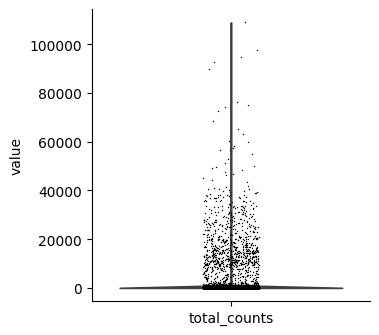

In [135]:
sc.pl.violin(zhang_ad_ile_fixed_female, 'total_counts')

In [136]:
use_cells = zhang_ad_ile_fixed_female.obs_names[
    (zhang_ad_ile_fixed_female.obs["total_counts"] > 10000)
    & (zhang_ad_ile_fixed_female.obs["total_counts"] < 30000)
]
zhang_ad_ile_fixed_female = zhang_ad_ile_fixed_female[use_cells, :]

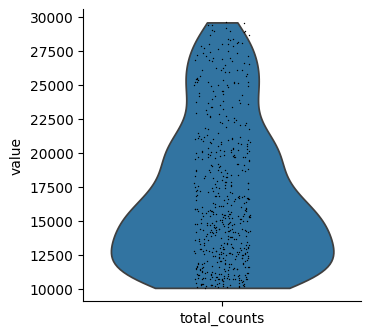

In [137]:
sc.pl.violin(zhang_ad_ile_fixed_female, 'total_counts')

In [138]:
sc.pp.filter_cells(zhang_ad_ile_fixed_female, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [139]:
sc.pp.filter_genes(zhang_ad_ile_fixed_female, min_cells=50)

In [140]:
sc.pp.normalize_total(zhang_ad_ile_fixed_female, target_sum=1e4)
zhang_ad_ile_fixed_female.layers["normalized_counts"] = zhang_ad_ile_fixed_female.X.copy()

log_transform(zhang_ad_ile_fixed_female)
zhang_ad_ile_fixed_female.layers["logcounts"] = zhang_ad_ile_fixed_female.X.copy()

In [141]:
sc.pp.highly_variable_genes(zhang_ad_ile_fixed_female, flavor="cell_ranger", n_top_genes=2000)

In [142]:
sc.tl.pca(zhang_ad_ile_fixed_female, mask_var="highly_variable")

In [143]:
sc.pp.neighbors(zhang_ad_ile_fixed_female, use_rep="X_pca")
sc.tl.umap(zhang_ad_ile_fixed_female)

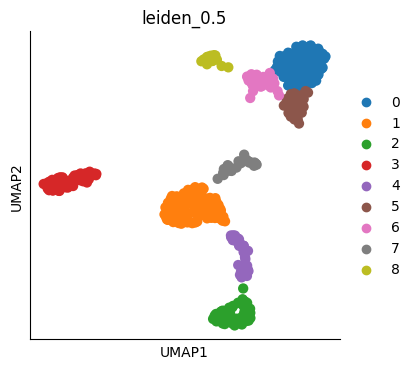

In [144]:
sc.tl.leiden(zhang_ad_ile_fixed_female, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_ile_fixed_female, color="leiden_0.5")

In [145]:
sc.pp.scrublet(zhang_ad_ile_fixed_female)

In [146]:
zhang_ad_ile_fixed_female.obs["log_n_counts"] = np.log10(zhang_ad_ile_fixed_female.obs["total_counts"])

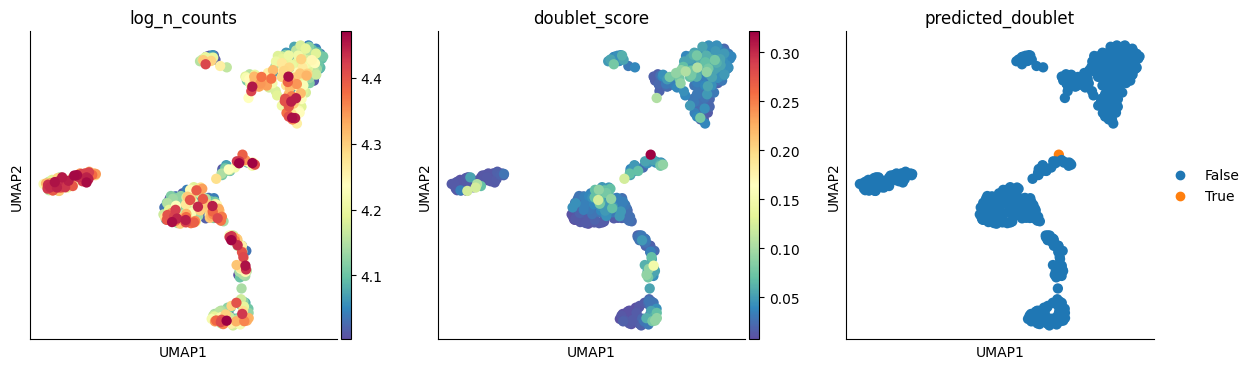

In [147]:
sc.pl.umap(zhang_ad_ile_fixed_female, color=["log_n_counts", "doublet_score", "predicted_doublet"])

In [148]:
zhang_ad_ile_fixed_female.shape

(545, 11584)

In [149]:
zhang_ad_ile_fixed_female = zhang_ad_ile_fixed_female[zhang_ad_ile_fixed_female.obs['predicted_doublet'] == False].copy()
zhang_ad_ile_fixed_female.shape

(544, 11584)

In [150]:
sc.pp.highly_variable_genes(zhang_ad_ile_fixed_female, flavor="cell_ranger", n_top_genes=2000)

In [151]:
sc.tl.pca(zhang_ad_ile_fixed_female, mask_var="highly_variable")

In [152]:
sc.pp.neighbors(zhang_ad_ile_fixed_female, use_rep="X_pca")
sc.tl.umap(zhang_ad_ile_fixed_female)

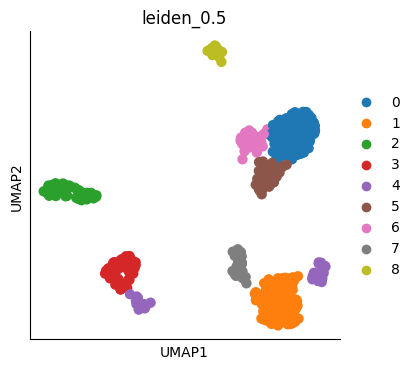

In [153]:
sc.tl.leiden(zhang_ad_ile_fixed_female, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_ile_fixed_female, color="leiden_0.5")

In [154]:
zhang_ad_ile_fixed_female.obs['run'] = 'Run0052 Female Fixed Ileum' 

In [155]:
zhang_ad_ile_fixed_female.var = zhang_ad_ile_fixed_female.var.drop(columns={'gene_name'})

In [156]:
zhang_ad_ile_fixed_female.write_h5ad('may_zhang_female_52_ileum_fixed_preprocessed.h5ad')

### Colon (unfixed)

In [157]:
zhang_ad_col_female = sc.read_mtx(input_dir + 'GSM4635433_10x-Run0052_Female-Colon-Neurons-Unfixed_matrix.mtx.gz')
zhang_ad_col_female

AnnData object with n_obs × n_vars = 30211 × 6794880

In [158]:
barcodes = pd.read_csv(input_dir + 'GSM4635433_10x-Run0052_Female-Colon-Neurons-Unfixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [159]:
genes = pd.read_csv(input_dir + 'GSM4635433_10x-Run0052_Female-Colon-Neurons-Unfixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [160]:
zhang_ad_col_female = zhang_ad_col_female.T 
zhang_ad_col_female.obs = barcodes
zhang_ad_col_female.var = genes
zhang_ad_col_female.var_names_make_unique()
zhang_ad_col_female

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [161]:
zhang_ad_col_female.var_names = zhang_ad_col_female.var['gene_name']
zhang_ad_col_female.obs_names = zhang_ad_col_female.obs['barcode']
zhang_ad_col_female.layers['raw_counts'] = zhang_ad_col_female.X.copy()

In [162]:
zhang_ad_col_female.var["mt"] = zhang_ad_col_female.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_col_female,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [163]:
zhang_ad_col_female.var_names_make_unique()

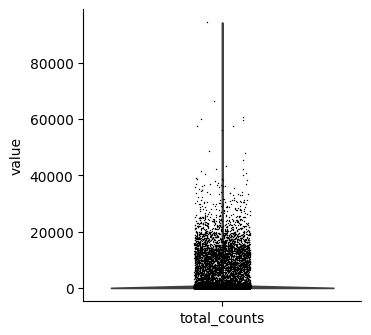

In [164]:
sc.pl.violin(zhang_ad_col_female, 'total_counts')

In [165]:
use_cells = zhang_ad_col_female.obs_names[
    (zhang_ad_col_female.obs["total_counts"] > 1000)
    & (zhang_ad_col_female.obs["total_counts"] < 30000)
]
zhang_ad_col_female = zhang_ad_col_female[use_cells, :]

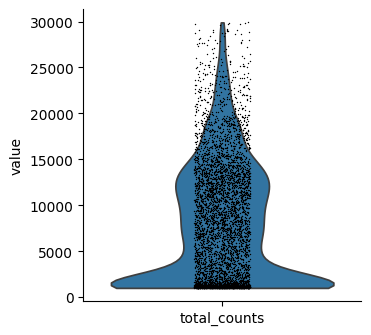

In [166]:
sc.pl.violin(zhang_ad_col_female, 'total_counts')

In [167]:
use_cells = zhang_ad_col_female.obs_names[
    (zhang_ad_col_female.obs["total_counts"] > 5000)
    & (zhang_ad_col_female.obs["total_counts"] < 25000)
]
zhang_ad_col_female = zhang_ad_col_female[use_cells, :]

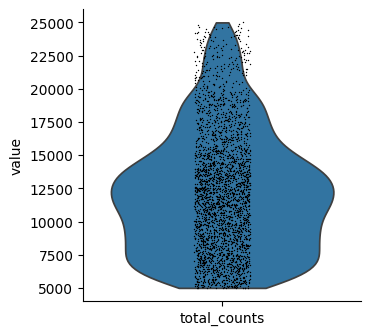

In [168]:
sc.pl.violin(zhang_ad_col_female, 'total_counts')

In [169]:
sc.pp.filter_cells(zhang_ad_col_female, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [170]:
sc.pp.filter_genes(zhang_ad_col_female, min_cells=50)

In [171]:
sc.pp.normalize_total(zhang_ad_col_female, target_sum=1e4)
zhang_ad_col_female.layers["normalized_counts"] = zhang_ad_col_female.X.copy()

log_transform(zhang_ad_col_female)
zhang_ad_col_female.layers["logcounts"] = zhang_ad_col_female.X.copy()

In [172]:
sc.pp.highly_variable_genes(zhang_ad_col_female, flavor="cell_ranger", n_top_genes=2000)

In [173]:
sc.tl.pca(zhang_ad_col_female, mask_var="highly_variable")

In [174]:
sc.pp.neighbors(zhang_ad_col_female, use_rep="X_pca")
sc.tl.umap(zhang_ad_col_female)

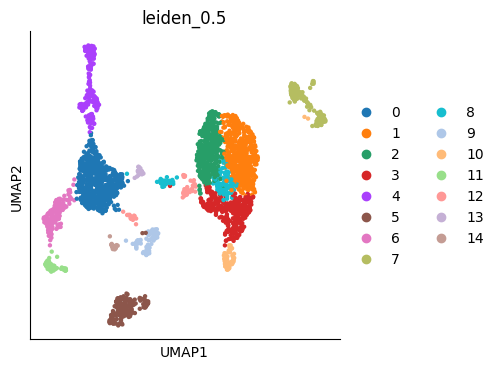

In [175]:
sc.tl.leiden(zhang_ad_col_female, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_col_female, color="leiden_0.5")

In [176]:
sc.pp.scrublet(zhang_ad_col_female)

In [177]:
zhang_ad_col_female.obs["log_n_counts"] = np.log10(zhang_ad_col_female.obs["total_counts"])

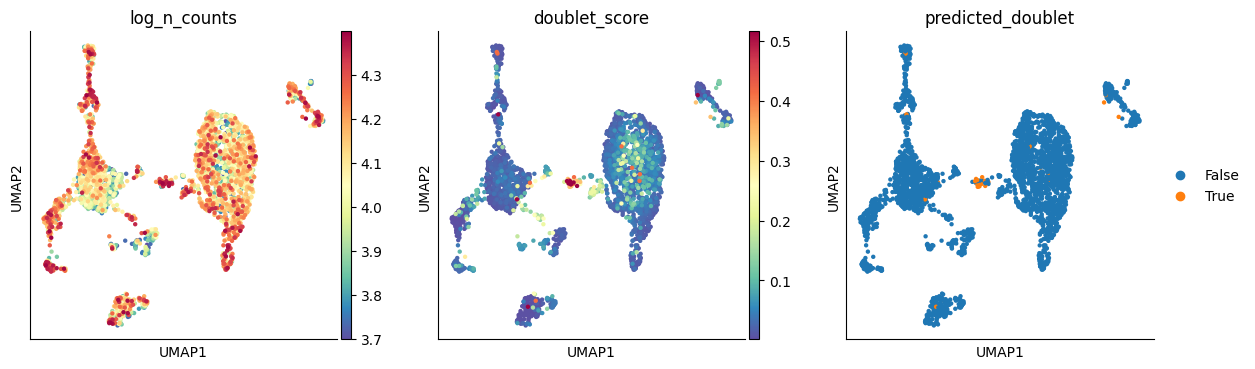

In [178]:
sc.pl.umap(zhang_ad_col_female, color=["log_n_counts", "doublet_score", "predicted_doublet"])

In [179]:
zhang_ad_col_female.shape

(3008, 14156)

In [180]:
zhang_ad_col_female = zhang_ad_col_female[zhang_ad_col_female.obs['predicted_doublet'] == False].copy()
zhang_ad_col_female.shape

(2973, 14156)

In [181]:
sc.pp.highly_variable_genes(zhang_ad_col_female, flavor="cell_ranger", n_top_genes=2000)

In [182]:
sc.tl.pca(zhang_ad_col_female, mask_var="highly_variable")

In [183]:
sc.pp.neighbors(zhang_ad_col_female, use_rep="X_pca")
sc.tl.umap(zhang_ad_col_female)

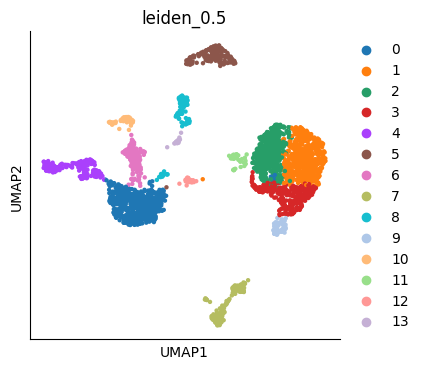

In [184]:
sc.tl.leiden(zhang_ad_col_female, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_col_female, color="leiden_0.5")

In [185]:
zhang_ad_col_female.obs['run'] = 'Run0052 Female Unfixed Colon' 

In [186]:
zhang_ad_col_unfixed_female = zhang_ad_col_female.copy()

In [187]:
zhang_ad_col_unfixed_female.var = zhang_ad_col_unfixed_female.var.drop(columns={'gene_name'})

In [188]:
zhang_ad_col_unfixed_female.write_h5ad('may_zhang_female_52_colon_unfixed_preprocessed.h5ad')

# Female - Run 72

### Duodenum

In [189]:
input_dir = 'datasets/May-Zhang et al/Run0072_Female/'

In [190]:
zhang_ad_duo_female_2 = sc.read_mtx(input_dir + 'GSM4635446_10x-Run0072_Female-Duodenum-Neurons-Fixed_matrix.mtx.gz')
zhang_ad_duo_female_2

AnnData object with n_obs × n_vars = 30211 × 6794880

In [191]:
barcodes = pd.read_csv(input_dir + 'GSM4635446_10x-Run0072_Female-Duodenum-Neurons-Fixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [192]:
genes = pd.read_csv(input_dir + 'GSM4635446_10x-Run0072_Female-Duodenum-Neurons-Fixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [193]:
zhang_ad_duo_female_2 = zhang_ad_duo_female_2.T 
zhang_ad_duo_female_2.obs = barcodes
zhang_ad_duo_female_2.var = genes
zhang_ad_duo_female_2.var_names_make_unique()
zhang_ad_duo_female_2

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [194]:
zhang_ad_duo_female_2.var_names = zhang_ad_duo_female_2.var['gene_name']
zhang_ad_duo_female_2.obs_names = zhang_ad_duo_female_2.obs['barcode']
zhang_ad_duo_female_2.layers['raw_counts'] = zhang_ad_duo_female_2.X.copy()

In [195]:
zhang_ad_duo_female_2.var["mt"] = zhang_ad_duo_female_2.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_duo_female_2,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [196]:
zhang_ad_duo_female_2.var_names_make_unique()

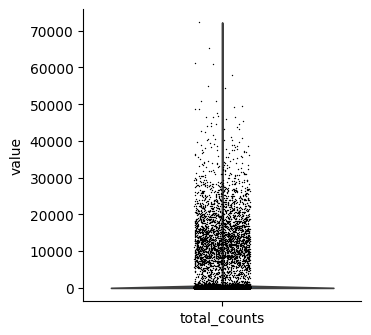

In [197]:
sc.pl.violin(zhang_ad_duo_female_2, 'total_counts')

In [198]:
use_cells = zhang_ad_duo_female_2.obs_names[
    (zhang_ad_duo_female_2.obs["total_counts"] > 5000)
    & (zhang_ad_duo_female_2.obs["total_counts"] < 30000)
]
zhang_ad_duo_female_2 = zhang_ad_duo_female_2[use_cells, :]

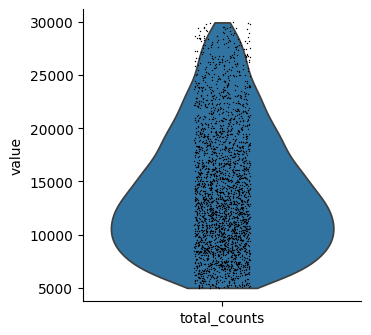

In [199]:
sc.pl.violin(zhang_ad_duo_female_2, 'total_counts')

In [200]:
sc.pp.filter_cells(zhang_ad_duo_female_2, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [201]:
sc.pp.filter_genes(zhang_ad_duo_female_2, min_cells=50)

In [202]:
sc.pp.normalize_total(zhang_ad_duo_female_2, target_sum=1e4)
zhang_ad_duo_female_2.layers["normalized_counts"] = zhang_ad_duo_female_2.X.copy()

log_transform(zhang_ad_duo_female_2)
zhang_ad_duo_female_2.layers["logcounts"] = zhang_ad_duo_female_2.X.copy()

In [203]:
sc.pp.highly_variable_genes(zhang_ad_duo_female_2, flavor="cell_ranger", n_top_genes=2000)

In [204]:
sc.tl.pca(zhang_ad_duo_female_2, mask_var="highly_variable")

In [205]:
sc.pp.neighbors(zhang_ad_duo_female_2, use_rep="X_pca")
sc.tl.umap(zhang_ad_duo_female_2)

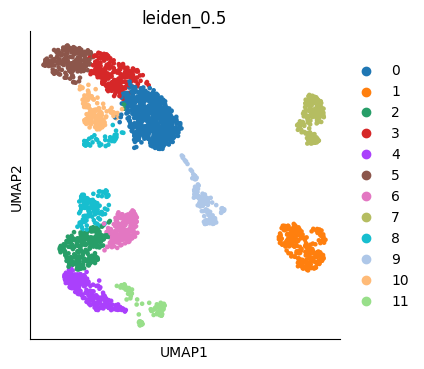

In [206]:
sc.tl.leiden(zhang_ad_duo_female_2, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_duo_female_2, color="leiden_0.5")

In [207]:
sc.pp.scrublet(zhang_ad_duo_female_2)

In [208]:
zhang_ad_duo_female_2.obs["log_n_counts"] = np.log10(zhang_ad_duo_female_2.obs["total_counts"])

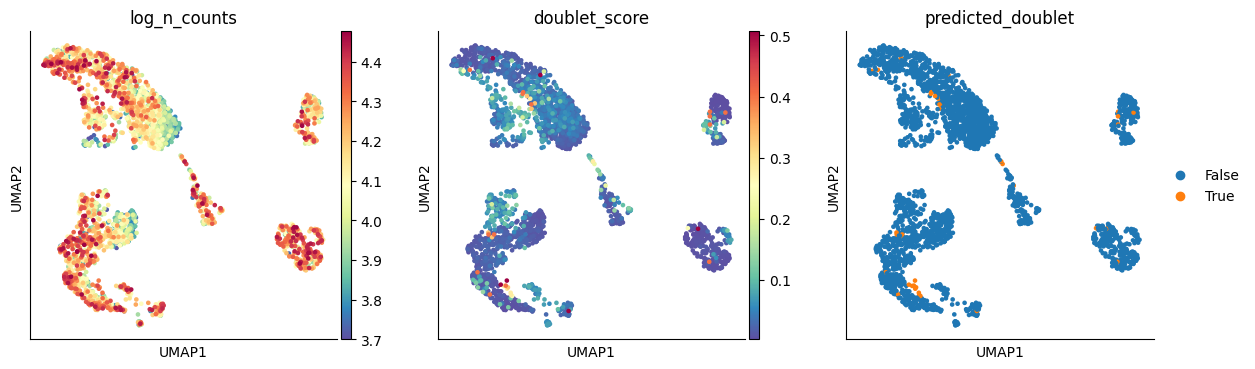

In [209]:
sc.pl.umap(zhang_ad_duo_female_2, color=["log_n_counts", "doublet_score", "predicted_doublet"])

In [210]:
zhang_ad_duo_female_2.shape

(2723, 14144)

In [211]:
zhang_ad_duo_female_2 = zhang_ad_duo_female_2[zhang_ad_duo_female_2.obs['predicted_doublet'] == False].copy()
zhang_ad_duo_female_2.shape

(2686, 14144)

In [212]:
sc.pp.highly_variable_genes(zhang_ad_duo_female_2, flavor="cell_ranger", n_top_genes=2000)

In [213]:
sc.tl.pca(zhang_ad_duo_female_2, mask_var="highly_variable")

In [214]:
sc.pp.neighbors(zhang_ad_duo_female_2, use_rep="X_pca")
sc.tl.umap(zhang_ad_duo_female_2)

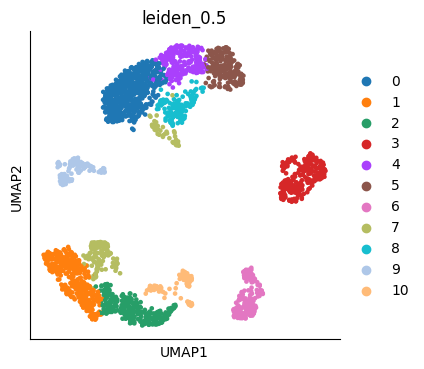

In [215]:
sc.tl.leiden(zhang_ad_duo_female_2, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_duo_female_2, color="leiden_0.5")

In [216]:
zhang_ad_duo_female_2.obs['run'] = 'Run0072 Female Fixed Duodenum' 

In [217]:
zhang_ad_duo_female_2.var = zhang_ad_duo_female_2.var.drop(columns={'gene_name'})

In [218]:
zhang_ad_duo_female_2.write_h5ad('may_zhang_female_72_duodenum_preprocessed.h5ad')

### Ileum

In [232]:
zhang_ad_ile_female_2 = sc.read_mtx(input_dir + 'GSM4635442_10x-Run0072-Female-Ileum-Neurons-Fixed_matrix.mtx.gz')
zhang_ad_ile_female_2

AnnData object with n_obs × n_vars = 30211 × 6794880

In [233]:
barcodes = pd.read_csv(input_dir + 'GSM4635442_10x-Run0072-Female-Ileum-Neurons-Fixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [234]:
genes = pd.read_csv(input_dir + 'GSM4635442_10x-Run0072-Female-Ileum-Neurons-Fixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [235]:
zhang_ad_ile_female_2 = zhang_ad_ile_female_2.T 
zhang_ad_ile_female_2.obs = barcodes
zhang_ad_ile_female_2.var = genes
zhang_ad_ile_female_2.var_names_make_unique()
zhang_ad_ile_female_2

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [236]:
zhang_ad_ile_female_2.var_names = zhang_ad_ile_female_2.var['gene_name']
zhang_ad_ile_female_2.obs_names = zhang_ad_ile_female_2.obs['barcode']
zhang_ad_ile_female_2.layers['raw_counts'] = zhang_ad_ile_female_2.X.copy()

In [237]:
zhang_ad_ile_female_2.var["mt"] = zhang_ad_ile_female_2.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_ile_female_2,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [238]:
zhang_ad_ile_female_2.var_names_make_unique()

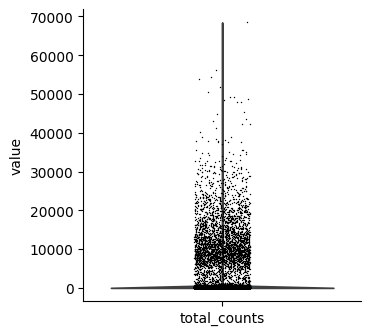

In [239]:
sc.pl.violin(zhang_ad_ile_female_2, 'total_counts')

In [240]:
use_cells = zhang_ad_ile_female_2.obs_names[
    (zhang_ad_ile_female_2.obs["total_counts"] > 5000)
    & (zhang_ad_ile_female_2.obs["total_counts"] < 25000)
]
zhang_ad_ile_female_2 = zhang_ad_ile_female_2[use_cells, :]

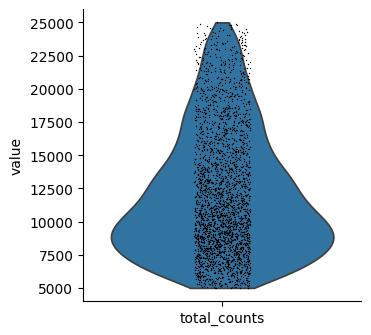

In [241]:
sc.pl.violin(zhang_ad_ile_female_2, 'total_counts')

In [242]:
sc.pp.filter_cells(zhang_ad_ile_female_2, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [243]:
sc.pp.filter_genes(zhang_ad_ile_female_2, min_cells=50)

In [244]:
sc.pp.normalize_total(zhang_ad_ile_female_2, target_sum=1e4)
zhang_ad_ile_female_2.layers["normalized_counts"] = zhang_ad_ile_female_2.X.copy()

log_transform(zhang_ad_ile_female_2)
zhang_ad_ile_female_2.layers["logcounts"] = zhang_ad_ile_female_2.X.copy()

In [245]:
sc.pp.highly_variable_genes(zhang_ad_ile_female_2, flavor="cell_ranger", n_top_genes=2000)

In [246]:
sc.tl.pca(zhang_ad_ile_female_2, mask_var="highly_variable")

In [247]:
sc.pp.neighbors(zhang_ad_ile_female_2, use_rep="X_pca")
sc.tl.umap(zhang_ad_ile_female_2)

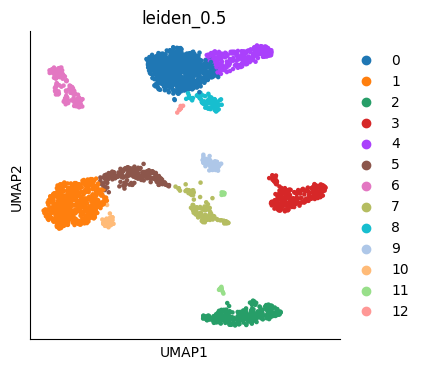

In [248]:
sc.tl.leiden(zhang_ad_ile_female_2, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_ile_female_2, color="leiden_0.5")

In [249]:
sc.pp.scrublet(zhang_ad_ile_female_2)

In [250]:
zhang_ad_ile_female_2.obs["log_n_counts"] = np.log10(zhang_ad_ile_female_2.obs["total_counts"])

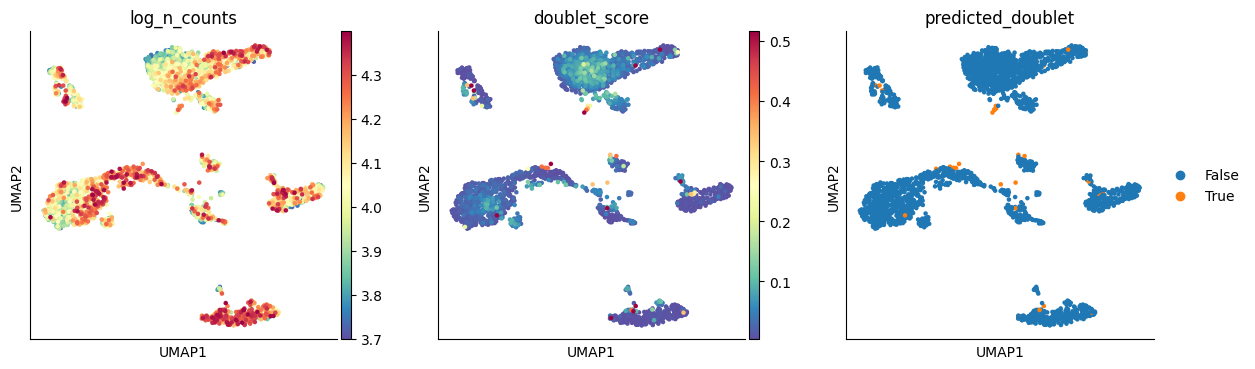

In [251]:
sc.pl.umap(zhang_ad_ile_female_2, color=["log_n_counts", "doublet_score", "predicted_doublet"])

In [252]:
zhang_ad_ile_female_2.shape

(2822, 13981)

In [253]:
zhang_ad_ile_female_2 = zhang_ad_ile_female_2[zhang_ad_ile_female_2.obs['predicted_doublet'] == False].copy()
zhang_ad_ile_female_2.shape

(2786, 13981)

In [254]:
sc.pp.highly_variable_genes(zhang_ad_ile_female_2, flavor="cell_ranger", n_top_genes=2000)

In [255]:
sc.tl.pca(zhang_ad_ile_female_2, mask_var="highly_variable")

In [256]:
sc.pp.neighbors(zhang_ad_ile_female_2, use_rep="X_pca")
sc.tl.umap(zhang_ad_ile_female_2)

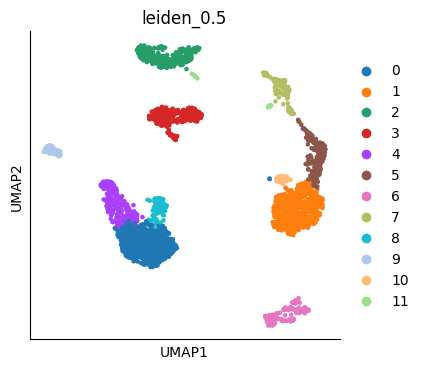

In [257]:
sc.tl.leiden(zhang_ad_ile_female_2, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_ile_female_2, color="leiden_0.5")

In [258]:
zhang_ad_ile_female_2.obs['run'] = 'Run0072 Female Fixed Ileum' 

In [259]:
zhang_ad_ile_female_2.var = zhang_ad_ile_female_2.var.drop(columns={'gene_name'})

In [260]:
zhang_ad_ile_female_2.write_h5ad('may_zhang_female_72_ileum_preprocessed.h5ad')

### Colon

In [261]:
zhang_ad_col_female_2 = sc.read_mtx(input_dir + 'GSM4635434_10x-Run0072_Female-Colon-Neurons-Fixed_matrix.mtx.gz')
zhang_ad_col_female_2

AnnData object with n_obs × n_vars = 30211 × 6794880

In [262]:
barcodes = pd.read_csv(input_dir + 'GSM4635434_10x-Run0072_Female-Colon-Neurons-Fixed_barcodes.tsv.gz', sep='\t', header=None) 
barcodes = barcodes.rename(columns={0:'barcode'})

In [263]:
genes = pd.read_csv(input_dir + 'GSM4635434_10x-Run0072_Female-Colon-Neurons-Fixed_features.tsv.gz', sep='\t', header=None) 
genes = genes.rename(columns={0:'gene_id', 1:'gene_name', 2:'feature_type'})

In [264]:
zhang_ad_col_female_2 = zhang_ad_col_female_2.T 
zhang_ad_col_female_2.obs = barcodes
zhang_ad_col_female_2.var = genes
zhang_ad_col_female_2.var_names_make_unique()
zhang_ad_col_female_2

AnnData object with n_obs × n_vars = 6794880 × 30211
    obs: 'barcode'
    var: 'gene_id', 'gene_name', 'feature_type'

In [265]:
zhang_ad_col_female_2.var_names = zhang_ad_col_female_2.var['gene_name']
zhang_ad_col_female_2.obs_names = zhang_ad_col_female_2.obs['barcode']
zhang_ad_col_female_2.layers['raw_counts'] = zhang_ad_col_female_2.X.copy()

In [266]:
zhang_ad_col_female_2.var["mt"] = zhang_ad_col_female_2.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    zhang_ad_col_female_2,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

In [267]:
zhang_ad_col_female_2.var_names_make_unique()

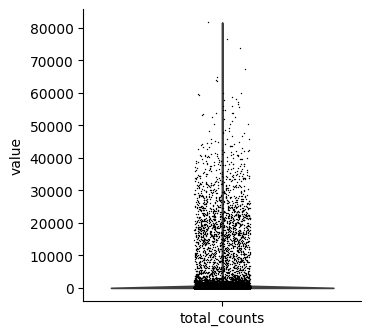

In [268]:
sc.pl.violin(zhang_ad_col_female_2, 'total_counts')

In [269]:
use_cells = zhang_ad_col_female_2.obs_names[
    (zhang_ad_col_female_2.obs["total_counts"] > 1000)
    & (zhang_ad_col_female_2.obs["total_counts"] < 30000)
]
zhang_ad_col_female_2 = zhang_ad_col_female_2[use_cells, :]

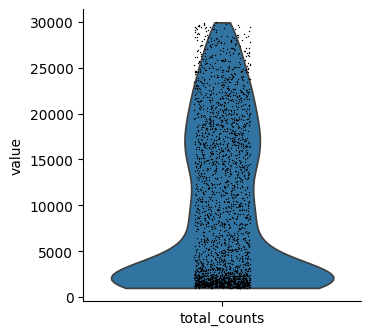

In [270]:
sc.pl.violin(zhang_ad_col_female_2, 'total_counts')

In [271]:
sc.pp.filter_cells(zhang_ad_col_female_2, min_genes=1)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:168: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


In [272]:
sc.pp.filter_genes(zhang_ad_col_female_2, min_cells=50)

In [273]:
sc.pp.normalize_total(zhang_ad_col_female_2, target_sum=1e4)
zhang_ad_col_female_2.layers["normalized_counts"] = zhang_ad_col_female_2.X.copy()

log_transform(zhang_ad_col_female_2)
zhang_ad_col_female_2.layers["logcounts"] = zhang_ad_col_female_2.X.copy()

In [274]:
sc.pp.highly_variable_genes(zhang_ad_col_female_2, flavor="cell_ranger", n_top_genes=2000)

In [275]:
sc.tl.pca(zhang_ad_col_female_2, mask_var="highly_variable")

In [276]:
sc.pp.neighbors(zhang_ad_col_female_2, use_rep="X_pca")
sc.tl.umap(zhang_ad_col_female_2)

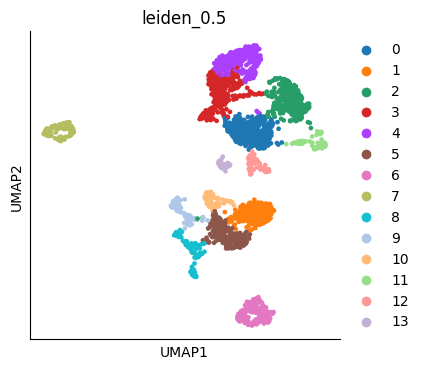

In [277]:
sc.tl.leiden(zhang_ad_col_female_2, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_col_female_2, color="leiden_0.5")

In [278]:
sc.pp.scrublet(zhang_ad_col_female_2)

In [279]:
zhang_ad_col_female_2.obs["log_n_counts"] = np.log10(zhang_ad_col_female_2.obs["total_counts"])

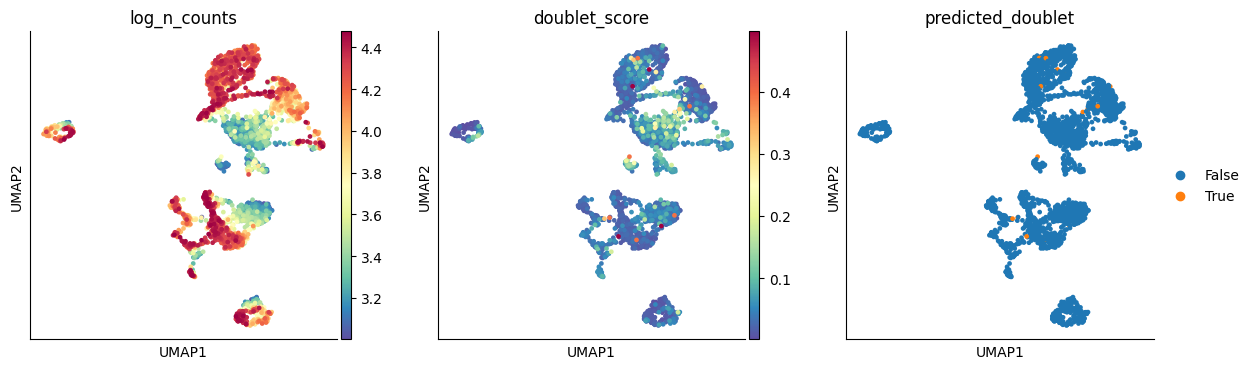

In [280]:
sc.pl.umap(zhang_ad_col_female_2, color=["log_n_counts", "doublet_score", "predicted_doublet"])

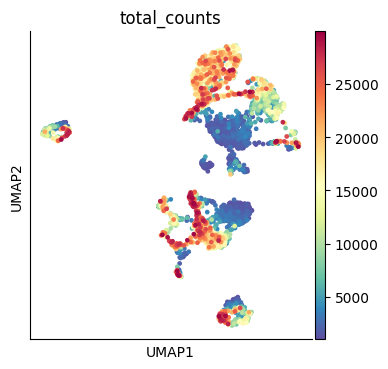

In [281]:
sc.pl.umap(zhang_ad_col_female_2, color=["total_counts"])

In [282]:
zhang_ad_col_female_2.shape

(2594, 12488)

In [283]:
zhang_ad_col_female_2 = zhang_ad_col_female_2[(zhang_ad_col_female_2.obs['predicted_doublet'] == False) & (zhang_ad_col_female_2.obs['total_counts'] > 10000)].copy()
zhang_ad_col_female_2.shape

(1139, 12488)

In [284]:
sc.pp.highly_variable_genes(zhang_ad_col_female_2, flavor="cell_ranger", n_top_genes=2000)

In [285]:
sc.tl.pca(zhang_ad_col_female_2, mask_var="highly_variable")

In [286]:
sc.pp.neighbors(zhang_ad_col_female_2, use_rep="X_pca")
sc.tl.umap(zhang_ad_col_female_2)

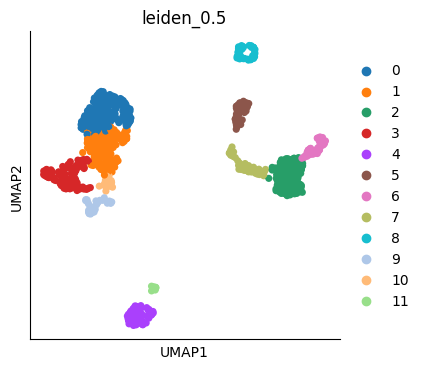

In [287]:
sc.tl.leiden(zhang_ad_col_female_2, resolution=0.5, key_added="leiden_0.5")
sc.pl.umap(zhang_ad_col_female_2, color="leiden_0.5")

In [288]:
zhang_ad_col_female_2.obs['run'] = 'Run0072 Female Fixed Colon' 

In [289]:
zhang_ad_col_female_2.var = zhang_ad_col_female_2.var.drop(columns={'gene_name'})

In [ ]:
zhang_ad_col_female_2.write_h5ad('may_zhang_female_72_colon_preprocessed.h5ad')